In [1]:
! pip install -e .
! pip install rapidfuzz
! pip install fiona

Obtaining file:///home/jovyan/Precipitation_paper
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for precip_helper (pyproject.toml) ... done
  Created wheel for precip_helper: filename=precip_helper-0.1.0-0.editable-py3-none-any.whl size=1296 sha256=db148ad5986b22d511f31658ba8919238c1e7e996a7a2279f37803039de40ce0
  Stored in directory: /tmp/pip-ephem-wheel-cache-vefb777f/wheels/85/d6/fd/4a136e03179e7b1256a36ee322e2837d14b136d70771439837
Successfully built precip_helper
  Attempting uninstall: precip_helper
    Found existing installation: precip_helper 0.1.0
    Uninstalling precip_helper-0.1.0:
      Successfully uninstalled precip_helper-0.1.0
  Using cached rapidfuzz-3.14.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (12 kB)
Using cached rapidfuzz-3.14.5-cp312-cp312-manylinux_2_27

In [2]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os
import numpy as np

warnings.filterwarnings('ignore')
%matplotlib inline

%load_ext autoreload
%autoreload 2


from precip_helper.utils import read_in_fires_and_precip

In [3]:
fires = read_in_fires_and_precip()

In [4]:
import shapely.wkt


fname = gpd.read_file("s3://maap-ops-workspace/shared/zbecker/TESS_fire_spread/v10_output.parq")
#fname_new = gpd.read_file("s3://maap-ops-workspace/shared/zbecker/TESS_fire_spread/v10_output.parq")

#fname['geometry'] = fname['MTBS_geometry'].apply(shapely.wkt.loads)

In [5]:
#fname = gpd.GeoDataFrame(fname, geometry='geometry')
fname = fname.set_crs(epsg=9311)
fname = fname.to_crs(4326)


In [6]:
# Read in the IMSRs report datasets

imsr = pd.read_csv("/home/jovyan/Preparedness_level/IMRS_from_pub/gacc_activity.csv")
wf = pd.read_csv("/home/jovyan/Preparedness_level/IMRS_from_pub/wildfire_activity.csv")

In [7]:
print(f" of {fname.MTBS_Event_ID.nunique()} named MBTS fires in the dataset, {fname[(fname.numFEDSfires == 1) & (fname.numMTBSfires == 1)].MTBS_Event_ID.nunique()} had a single 1:1 FEDS match")

fname = fname[fname.numFEDSfires == 1] # Excuding complicated multi-fire merges right this second. 
fname = fname[fname.numMTBSfires == 1]

 of 4307 named MBTS fires in the dataset, 3355 had a single 1:1 FEDS match


In [8]:
## Using the MTBS geometry, I will match these fires to GACC and year. If they have the same name, the same year, and the same GACC, I am calling it a match. 

import re
from rapidfuzz import process, fuzz

In [9]:
# Sample Data with messy inputs (extra spaces, punctuation, mixed casing)
fname.loc[:, 'fire_name'] = fname.MTBS_Name

# --- 1. DATA CLEANING FUNCTION ---
def clean_text_column(series):
    """Cleans a Pandas Series of text strings for better fuzzy matching."""
    
    # 1. Convert to lowercase
    cleaned = series.str.lower()
    
    # 2. Remove punctuation (replaces anything that isn't a letter, number, or whitespace with nothing)
    cleaned = cleaned.str.replace(r'[^\w\s]', '', regex=True)
    
    # 3. Remove extra internal whitespace (replaces multiple spaces with a single space)
    cleaned = cleaned.str.replace(r'\s+', ' ', regex=True)
    
    # 4. Strip leading and trailing whitespace
    cleaned = cleaned.str.strip()
    
    # Optional: If you have common titles you want to strip out, you could chain another replace:
    #cleaned = cleaned.str.replace(r'\b(phd|mr|mrs|ms|jr|sr)\b', '', regex=True).str.strip()
    cleaned = cleaned.str.replace(r'\b(mf|cmplx|fire|complex)\b', '', regex=True).str.strip()
    return cleaned

# Apply cleaning to create new columns in both DataFrames
fname['Cleaned_Name'] = clean_text_column(fname['fire_name'])
wf['Cleaned_Name'] = clean_text_column(wf["fire_name"])


# --- 2. FUZZY MATCHING ---
def get_best_match(name, choices, scorer=fuzz.WRatio, score_cutoff=80):
    # Check for NaN/None to avoid errors
    if pd.isna(name):
        return None, None
        
    result = process.extractOne(name, choices, scorer=scorer, score_cutoff=score_cutoff)
    if result:
        return result[0], result[1] # Returns the matched string and the score
    return None, None

# Get a list of the CLEANED names to match against
choices = wf['Cleaned_Name'].tolist()

# Apply the function comparing the cleaned columns
fname[['Matched_Cleaned_Name', 'Match_Score']] = fname['Cleaned_Name'].apply(
    lambda x: pd.Series(get_best_match(x, choices))
)

fname[['fire_name', 'Cleaned_Name', 'Matched_Cleaned_Name', 'Match_Score']]

,fire_name,Cleaned_Name,Matched_Cleaned_Name,Match_Score
1,AUGUST COMPLEX,august,august,100.0
14,HERMITS PEAK,hermits peak,peak,90.0
15,CREEK,creek,creek,100.0
16,BLACK,black,black,100.0
17,HENNESSEY,hennessey,ss,90.0
...,...,...,...,...
4302,JIMMIE CREEK RD,jimmie creek rd,jimmie creek rd,100.0
4303,CALVIN LEE RD,calvin lee rd,calvin lee rd,100.0
4304,RICHARDVILLE BORDER FIRE,richardville border,richardville border,100.0
4305,BORDER 6,border 6,border,95.0


In [10]:
## Adding in the GACCS to mbts 

gsp = gpd.read_file("/home/jovyan/Preparedness_level/GACC_borders/National_GACC_Boundaries.shp")
gsp = gsp.to_crs("EPSG:4326")
gsp = gsp.dissolve(by='GACCAbbrev').reset_index()
#fname = fname.drop(columns="index_right")
fname = fname.sjoin(gsp[['GACCName', 'GACCAbbrev','geometry']], how = "left")

In [11]:
wf.loc[:, "date"] = pd.to_datetime(wf.imsr_date)
wf.loc[:, "year"] = wf.date.dt.year
fname = fname.rename(columns= {"GACCAbbrev": "gacc"})
fname = fname.rename(columns= {"Year": "year"})
fname.year = fname.year.astype("str")
wf.year = wf.year.astype("str")
wf.loc[:, 'Matched_Cleaned_Name'] = wf.Cleaned_Name

mf = fname[fname.Match_Score > 94.5].merge(wf, on  = ['Matched_Cleaned_Name',"gacc", "year" ]) # Needs a high sore, a matching year, and a matching gacc

In [12]:
## Joining together
foo = mf[mf.Matched_Cleaned_Name == "schneider springs"]
foo[['year', 'MTBS_Name', 
       'Matched_Cleaned_Name', 'Match_Score',
       'gacc', 'imsr_date', 'gacc_priority', 'fire_priority', 'fire_name_y', 'unit', 'fire_size',
       'fire_size_change', 'percent_containment', 'structures_lost', 'cost_to_date',
       ]]
print(foo.FEDS_matched_IDs.unique())

['[63036]']


In [13]:
### A single example

## Oh no! Maybe the ids don't match up between FEDS products

# plt.plot(foo.imsr_date.astype("datetime64[ns]"), foo.percent_containment, color = "green", label = "Pecent Containment")
# plt.plot(fires[fires.UfireID == "63036_2021"].t, fires[fires.UfireID == "63036_2021"].precipitation)



# # 2. Create the figure and the first axis
# fig, ax1 = plt.subplots(figsize=(8, 5))

# # 3. Plot the first dataset and label the axes
# color1 = 'tab:blue'
# ax1.set_xlabel('Time of fire')
# ax1.set_ylabel('Primary Y-Axis (Sin Wave)', color=color1)
# ax1.plot(foo.imsr_date.astype("datetime64[ns]"), foo.percent_containment, color=color1, linewidth=2, label= "% containted")
# ax1.tick_params(axis='y', labelcolor=color1)

# # 4. Create a second y-axis that shares the same x-axis
# ax2 = ax1.twinx()  

# # 5. Plot the second dataset and label the new y-axis
# color2 = 'tab:red'
# ax2.set_ylabel('Secondary Y-Axis (Exponential)', color=color2)
# ax2.plot(fires[fires.UfireID == "63036_2021"].t, fires[fires.UfireID == "63036_2021"].precipitation, color=color2, linewidth=2, linestyle='--', label='Precipitation mm/12hr')
# ax2.tick_params(axis='y', labelcolor=color2)

# # 6. (Optional) Add a title and grid
# plt.title('Schneider Springs Fire')


# # 7. Show the plot
# fig.tight_layout() # Ensures labels don't get cut off
# plt.show()

In [14]:
import geopandas as gpd
#import fiona
import zipfile

# # Define paths
# zip_file_path = "./operational_FGDB/Public_EventDataArchive_2021.gdb (1).zip"
# destination_dir = "./operational_FGDB/"

# # Extract all contents
# with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#     zip_ref.extractall(destination_dir)

# gdb_path = "path/to/your/dataset.gdb"

# # 1. List all available layers inside the GDB
# layers = fiona.listlayers(gdb_path)
# print("Available layers:", layers)

# # 2. Read a specific layer into a GeoDataFrame
# df = gpd.read_file(gdb_path, layer=layers[0])

# # 3. Inspect data
# print(df.head())

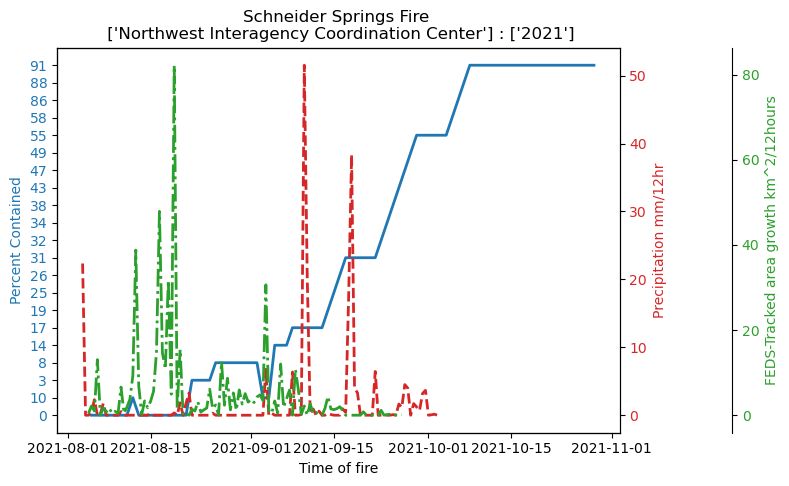

In [15]:
fig, ax1 = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(right=0.75) # Shrink main plot area to leave space on the right

# 3. Plot the FIRST dataset (Left Y-Axis)
color1 = 'tab:blue'
ax1.set_xlabel('Time of fire')
ax1.set_ylabel('Percent Contained', color=color1)
ax1.plot(foo.imsr_date.astype("datetime64[ns]"), foo.percent_containment, color=color1, linewidth=2, label= "% containted")
ax1.tick_params(axis='y', labelcolor=color1)

# 4. Plot the SECOND dataset (Right Y-Axis)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Precipitation mm/12hr', color=color2)
ax2.plot(fires[fires.UfireID == "63036_2021"].t, fires[fires.UfireID == "63036_2021"].precipitation, color=color2, linewidth=2, linestyle='--', label='Precipitation mm/12hr')
ax2.tick_params(axis='y', labelcolor=color2)

# 5. Plot the THIRD dataset (Offset Right Y-Axis)
ax3 = ax1.twinx()
color3 = 'tab:green'

# Offset the third axis to the right
# "axes" means offset by a fraction of the axes width (1.0 is the right edge, 1.2 is further right)
ax3.spines["right"].set_position(("axes", 1.2))

# Plot and format the third axis
ax3.set_ylabel('FEDS-Tracked area growth km^2/12hours', color=color3)
ax3.plot(fires[fires.UfireID == "63036_2021"].t, fires[fires.UfireID == "63036_2021"].area_growth_at_t_km2, color=color3, linewidth=2, linestyle='-.', label='Cos(x)*10')
ax3.tick_params(axis='y', labelcolor=color3)

# 6. Add title and grid
plt.title(f'Schneider Springs Fire \n {foo.GACCName.unique()} : {foo.year.unique()}')
plt.show()

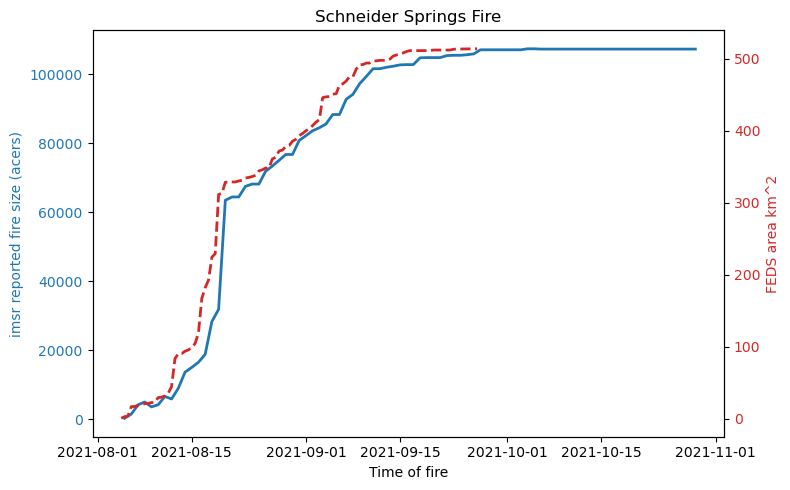

In [16]:
# 2. Create the figure and the first axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# 3. Plot the first dataset and label the axes
color1 = 'tab:blue'
ax1.set_xlabel('Time of fire')
ax1.set_ylabel('imsr reported fire size (acers)', color=color1)
ax1.plot(foo.imsr_date.astype("datetime64[ns]"), foo.fire_size, color=color1, linewidth=2, label= "% containted")
ax1.tick_params(axis='y', labelcolor=color1)

# 4. Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()  

# 5. Plot the second dataset and label the new y-axis
color2 = 'tab:red'
ax2.set_ylabel('FEDS area km^2', color=color2)
ax2.plot(fires[fires.UfireID == "63036_2021"].t, fires[fires.UfireID == "63036_2021"].area_growth_at_t_km2.cumsum(), color=color2, linewidth=2, linestyle='--', label='Precipitation mm/12hr')
ax2.tick_params(axis='y', labelcolor=color2)

# 6. (Optional) Add a title and grid
plt.title('Schneider Springs Fire')


# 7. Show the plot
fig.tight_layout() # Ensures labels don't get cut off
plt.show()

In [17]:
### You could do a new extraction? Using the MBTS data?

In [18]:
def explore_plot(fire_name, mf = mf, fires = fires):

    foo = mf[mf.Matched_Cleaned_Name == fire_name]
    uid = foo.FEDS_matched_IDs.str.strip('[]').astype(int).unique()
    UfireID = str(uid[0]) + "_" + str(*foo.year.unique())
    print(f'Fire {fire_name} from {foo.year.unique()} and id {foo.FEDS_matched_IDs.unique()} ')

    if len(fires[fires.UfireID == UfireID]) == 0:

        print(f"No fire found for {UfireID}")
        if(len(fires[fires.UfireID.str.contains(fire_name)]) > 0 ):
            print("Possible fires: ")
            print(fires[fires.UfireID.str.contains(fire_name)].UfireID.unique())
        return("")
    
    
    fig, ax1 = plt.subplots(figsize=(9, 5))
    fig.subplots_adjust(right=0.75) # Shrink main plot area to leave space on the right

    # 3. Plot the FIRST dataset (Left Y-Axis)
    color1 = 'tab:blue'
    ax1.set_xlabel('Time of fire')
    ax1.set_ylabel('Percent Contained', color=color1)
    ax1.plot(foo.imsr_date.astype("datetime64[ns]"), foo.percent_containment, color=color1, linewidth=2, label= "% containted")
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.tick_params(axis='x', labelrotation=90)
    
    
    # 4. Plot the SECOND dataset (Right Y-Axis)
    ax2 = ax1.twinx()  
    color2 = 'tab:red'
    ax2.set_ylabel('Precipitation mm/12hr', color=color2)
    ax2.plot(fires[fires.UfireID == UfireID].t, fires[fires.UfireID == UfireID].precipitation, color=color2, linewidth=2, linestyle='--', label='Precipitation mm/12hr')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # 5. Plot the THIRD dataset (Offset Right Y-Axis)
    ax3 = ax1.twinx()
    color3 = 'tab:green'
    
    # Offset the third axis to the right
    # "axes" means offset by a fraction of the axes width (1.0 is the right edge, 1.2 is further right)
    ax3.spines["right"].set_position(("axes", 1.2))
    
    # Plot and format the third axis
    ax3.set_ylabel('FEDS-Tracked area growth km^2/12hours', color=color3)
    ax3.plot(fires[fires.UfireID == UfireID].t, fires[fires.UfireID == UfireID].area_growth_at_t_km2, color=color3, linewidth=2, linestyle='-.')
    ax3.tick_params(axis='y', labelcolor=color3)
    plt.xticks(rotation=90)
    
    # 6. Add title and grid
    plt.title(f'{foo.MTBS_Name.unique()} Fire \n {foo.GACCName.unique()} : {foo.year.unique()}')
    plt.show()

    # 2. Create the figure and the first axis
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # 3. Plot the first dataset and label the axes
    color1 = 'tab:blue'
    ax1.set_xlabel('Time of fire')
    ax1.set_ylabel('imsr reported fire size (acers)', color=color1)
    ax1.plot(foo.imsr_date.astype("datetime64[ns]"), foo.fire_size, color=color1, linewidth=2, label= "% containted")
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.tick_params(axis='x', labelrotation=90)
    
    # 4. Create a second y-axis that shares the same x-axis
    ax2 = ax1.twinx()  
    
    # 5. Plot the second dataset and label the new y-axis
    color2 = 'tab:red'
    ax2.set_ylabel('FEDS area km^2', color=color2)
    ax2.plot(fires[fires.UfireID ==  UfireID].t, fires[fires.UfireID == UfireID].area_growth_at_t_km2.cumsum(), color=color2, linewidth=2, linestyle='--', label='Precipitation mm/12hr')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # 6. (Optional) Add a title and grid
    plt.title(f'{foo.MTBS_Name.unique()} Fire \n {foo.GACCName.unique()} : {foo.year.unique()}')
    
    
    # 7. Show the plot
    fig.tight_layout() # Ensures labels don't get cut off
    plt.show()

Fire whit from ['2016'] and id ['[64415]'] 


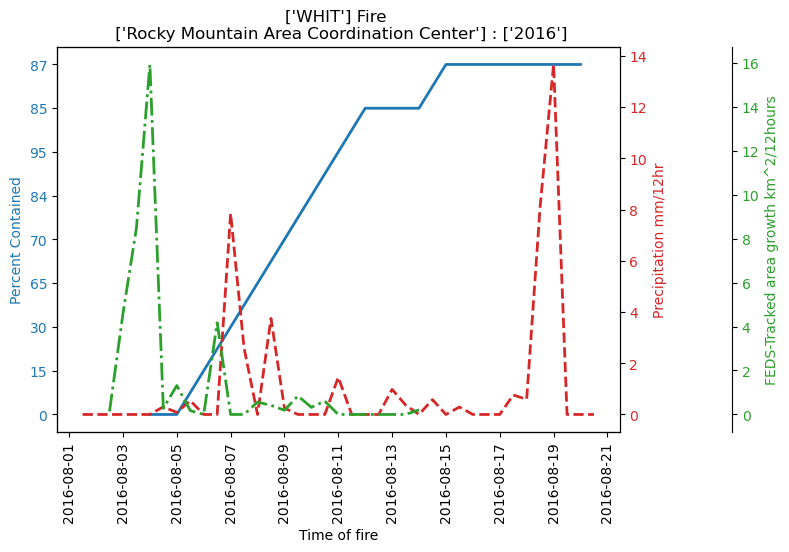

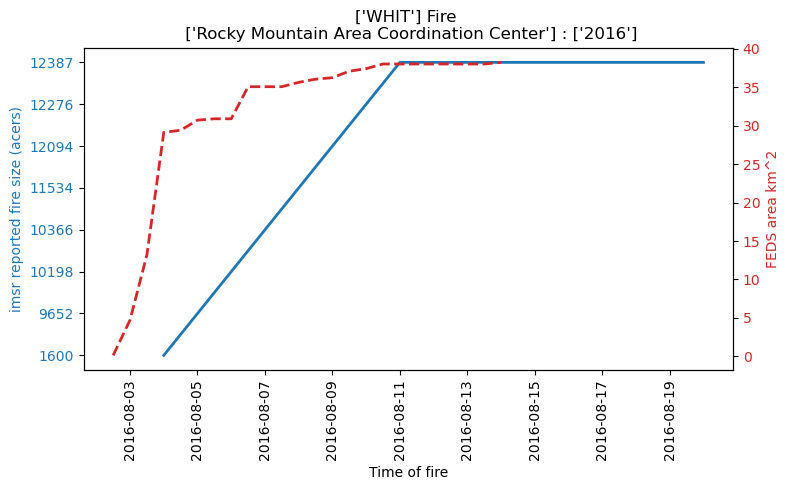

In [19]:
explore_plot("whit")